# Green BPM Guideline Survey — Analysis

Loads every `guidelines/<source>/guidelines.csv` (raw guideline data) and `survey_claude.csv`
(Claude-generated BPM relevance ratings) across all sources, and explores the results.

The human interview pass (`survey.csv`) is currently empty for every source — the last section
of this notebook is a comparison stub that will activate once real ratings are filled in.

**Sources:**
- `aws`, `azure`, `gcp` — cloud vendor Well-Architected sustainability pillars
- `gsf` — Green Software Foundation Patterns Catalog
- `w3c` — W3C Web Sustainability Guidelines
- `gbpp` — Green Business Process Patterns (Nowak et al., PLoP 2011) — BPM-native
- `ppatterns` — process-pattern.app, Sustainability-tagged patterns — BPM-native


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

REPO_ROOT = Path.cwd()
GUIDELINES_DIR = REPO_ROOT / "guidelines"

SOURCES = ["aws", "azure", "gcp", "gsf", "w3c", "gbpp", "ppatterns"]
BPM_NATIVE = {"gbpp", "ppatterns"}


## Load and merge all sources

In [2]:
def load_source(source):
    g_path = GUIDELINES_DIR / source / "guidelines.csv"
    s_path = GUIDELINES_DIR / source / "survey_claude.csv"

    guidelines = pd.read_csv(g_path, encoding="utf-8-sig")
    survey = pd.read_csv(s_path, encoding="utf-8-sig")

    merged = guidelines.merge(survey, on="ID", how="left", validate="one_to_one")
    merged.insert(0, "Source", source)
    merged["BPM Native"] = source in BPM_NATIVE
    return merged

frames = [load_source(s) for s in SOURCES]
df = pd.concat(frames, ignore_index=True)

# BPM Relevance / Generic come in as object dtype where any row is NaN; coerce explicitly
df["BPM Relevance"] = pd.to_numeric(df["BPM Relevance"], errors="coerce")

print(f"Loaded {len(df)} guidelines across {df['Source'].nunique()} sources")
df.head()


Loaded 415 guidelines across 7 sources


,Source,ID,Name,Category,Reference,Guideline,Keywords,BPM Relevance,BPM Scope,Generic,BPM Justification,BPM Lifecycle,Discussion,BPM Native
0,aws,AWS.Region.1,Choose Region based on both business requirements and sustainability goals,Region Selection,https://docs.aws.amazon.com/wellarchitected/latest/sustainability-pillar/sus...,Choose a Region for your workload based on both your business requirements a...,"region selection, hosting, carbon footprint",5,Infrastructure/Platform,Yes,Where the process engine and its workers are hosted directly shapes the carb...,Execution,NaN,False
1,aws,AWS.Demand.1,Scale workload infrastructure dynamically,Alignment to demand,https://docs.aws.amazon.com/wellarchitected/latest/sustainability-pillar/sus...,Use elasticity of the cloud and scale your infrastructure dynamically to mat...,"elasticity, autoscaling, demand-based capacity",5,Worker/Task,No,Scaling worker capacity dynamically to match the rate of incoming process in...,Execution,NaN,False
2,aws,AWS.Demand.2,Align SLAs with sustainability goals,Alignment to demand,https://docs.aws.amazon.com/wellarchitected/latest/sustainability-pillar/sus...,Review and optimize workload service-level agreements (SLA) based on your su...,"SLA, service level, sustainability trade-off",4,Organizational/Governance,No,SLAs such as response times or completion deadlines are frequently encoded d...,Design,NaN,False
3,aws,AWS.Demand.3,Stop the creation and maintenance of unused\r\n assets,Alignment to demand,https://docs.aws.amazon.com/wellarchitected/latest/sustainability-pillar/sus...,Decommission unused assets in your workload to reduce the number of cloud re...,"decommissioning, unused resources, cleanup",1,Infrastructure/Platform,Yes,Generic resource hygiene (decommissioning unused cloud assets) with no parti...,Not Applicable,NaN,False
4,aws,AWS.Demand.4,Optimize geographic placement of workloads based on their networking require...,Alignment to demand,https://docs.aws.amazon.com/wellarchitected/latest/sustainability-pillar/sus...,Select cloud location and services for your workload that reduce the distanc...,"geographic placement, networking, latency",2,Infrastructure/Platform,Yes,Placing services closer together to cut network hops could marginally affect...,Not Applicable,NaN,False


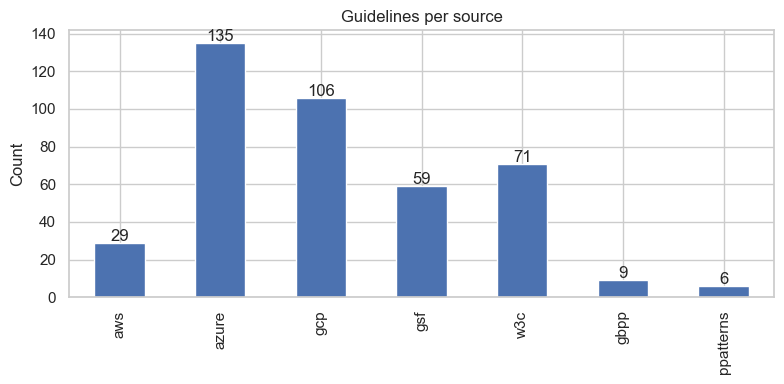

In [3]:
counts = df.groupby("Source").size().reindex(SOURCES)
ax = counts.plot(kind="bar", figsize=(8, 4), color="#4C72B0")
ax.set_title("Guidelines per source")
ax.set_ylabel("Count")
ax.set_xlabel("")
for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha="center")
plt.tight_layout()
plt.show()


## BPM Relevance distribution

`BPM Relevance` is a 0–5 scale (see `SURVEY_SCHEMA.md`): 0 = not relevant to BPM at all,
5 = directly and obviously relevant.


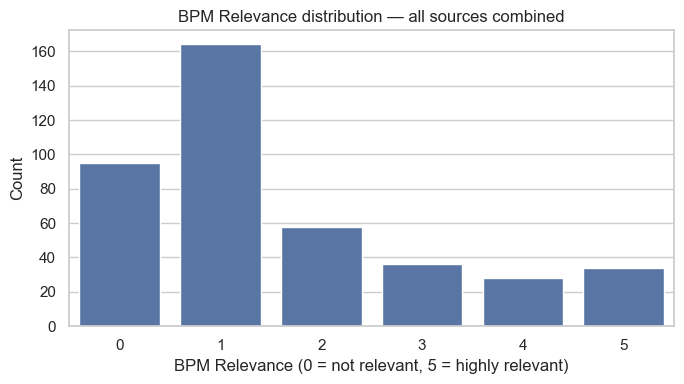

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="BPM Relevance", order=[0, 1, 2, 3, 4, 5], color="#4C72B0", ax=ax)
ax.set_title("BPM Relevance distribution — all sources combined")
ax.set_xlabel("BPM Relevance (0 = not relevant, 5 = highly relevant)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


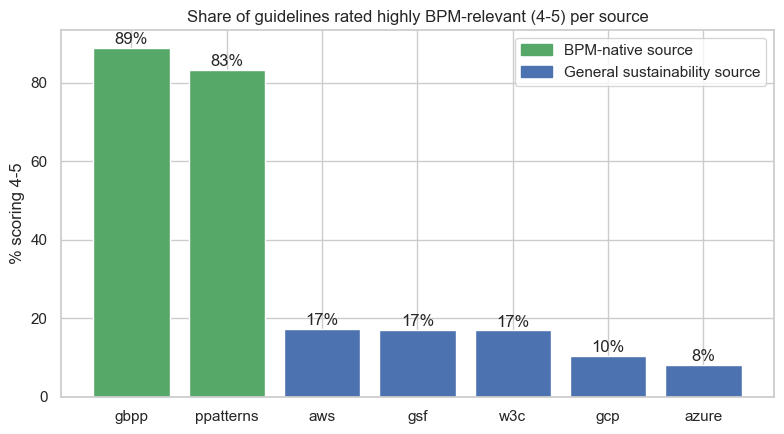

In [5]:
# % of guidelines scoring 4-5 ("highly relevant") per source, ordered high to low
high_share = (
    df.assign(high=df["BPM Relevance"] >= 4)
    .groupby("Source")["high"]
    .mean()
    .mul(100)
    .reindex(SOURCES)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#55A868" if s in BPM_NATIVE else "#4C72B0" for s in high_share.index]
bars = ax.bar(high_share.index, high_share.values, color=colors)
ax.set_title("Share of guidelines rated highly BPM-relevant (4-5) per source")
ax.set_ylabel("% scoring 4-5")
for bar, v in zip(bars, high_share.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1, f"{v:.0f}%", ha="center")
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color="#55A868", label="BPM-native source"),
        plt.Rectangle((0, 0), 1, 1, color="#4C72B0", label="General sustainability source"),
    ]
)
plt.tight_layout()
plt.show()


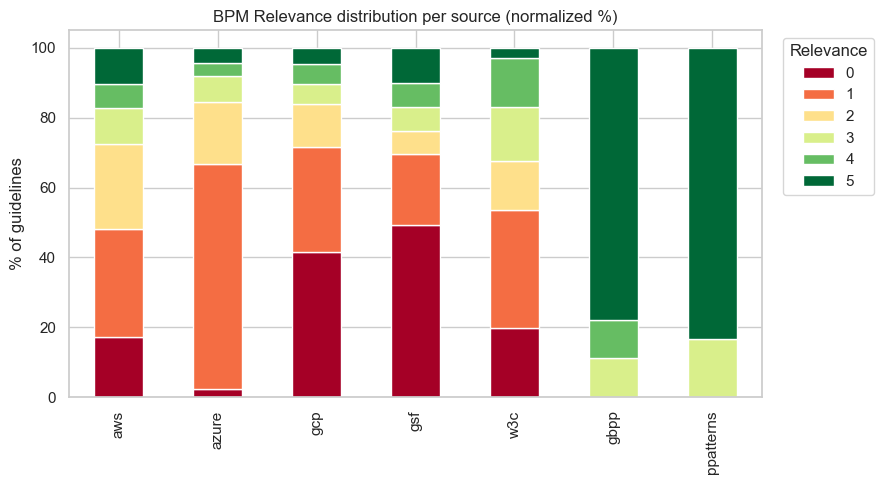

In [6]:
# Full relevance distribution per source, normalized to %, stacked
dist = (
    pd.crosstab(df["Source"], df["BPM Relevance"], normalize="index")
    .mul(100)
    .reindex(SOURCES)
)
dist = dist.reindex(columns=[0, 1, 2, 3, 4, 5], fill_value=0)

ax = dist.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="RdYlGn")
ax.set_title("BPM Relevance distribution per source (normalized %)")
ax.set_ylabel("% of guidelines")
ax.set_xlabel("")
ax.legend(title="Relevance", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## BPM Scope

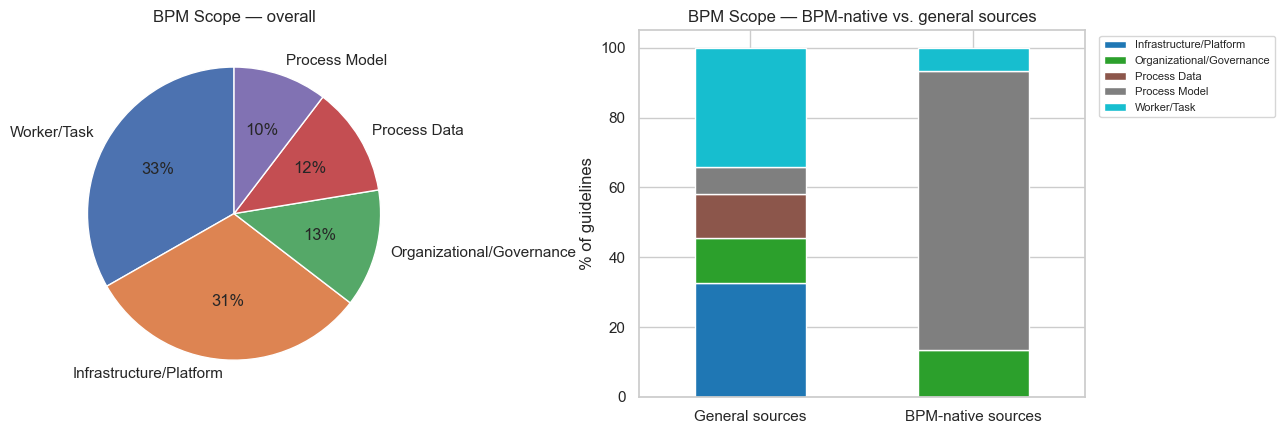

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

scope_counts = df["BPM Scope"].value_counts()
axes[0].pie(scope_counts.values, labels=scope_counts.index, autopct="%1.0f%%", startangle=90)
axes[0].set_title("BPM Scope — overall")

scope_by_native = (
    pd.crosstab(df["BPM Native"], df["BPM Scope"], normalize="index").mul(100)
)
scope_by_native.index = ["General sources", "BPM-native sources"]
scope_by_native.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab10")
axes[1].set_title("BPM Scope — BPM-native vs. general sources")
axes[1].set_ylabel("% of guidelines")
axes[1].set_xlabel("")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.setp(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


## Generic vs. BPM-specific

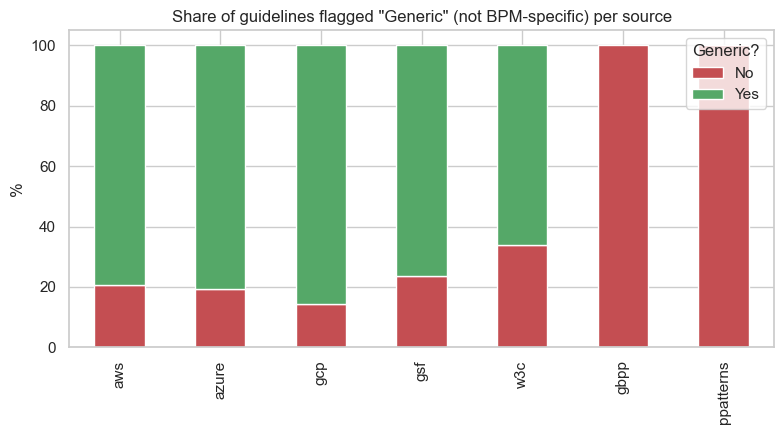

In [8]:
generic_share = (
    pd.crosstab(df["Source"], df["Generic"], normalize="index").mul(100).reindex(SOURCES)
)
ax = generic_share.plot(kind="bar", stacked=True, figsize=(8, 4.5), color=["#C44E52", "#55A868"])
ax.set_title('Share of guidelines flagged "Generic" (not BPM-specific) per source')
ax.set_ylabel("%")
ax.set_xlabel("")
ax.legend(title="Generic?")
plt.tight_layout()
plt.show()


## BPM Lifecycle coverage

`BPM Lifecycle` is a multi-select field (comma-separated), so it's exploded into one row per
phase before counting.


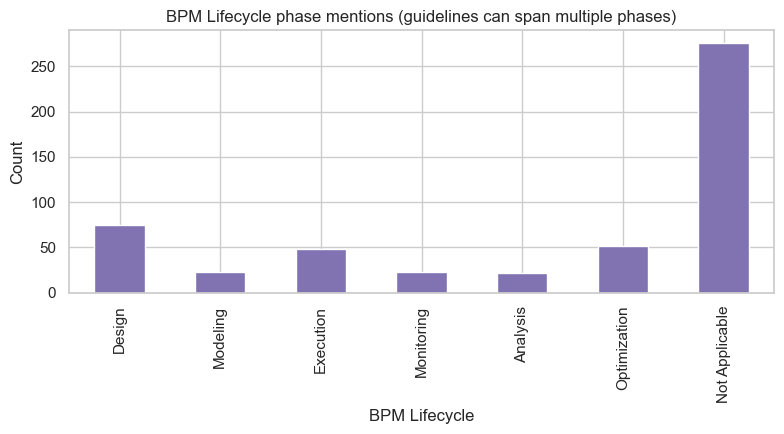

In [9]:
lifecycle_exploded = (
    df.dropna(subset=["BPM Lifecycle"])
    .assign(**{"BPM Lifecycle": df["BPM Lifecycle"].str.split(",")})
    .explode("BPM Lifecycle")
)
lifecycle_exploded["BPM Lifecycle"] = lifecycle_exploded["BPM Lifecycle"].str.strip()

phase_order = ["Design", "Modeling", "Execution", "Monitoring", "Analysis", "Optimization", "Not Applicable"]
phase_counts = lifecycle_exploded["BPM Lifecycle"].value_counts().reindex(phase_order, fill_value=0)

ax = phase_counts.plot(kind="bar", figsize=(8, 4.5), color="#8172B2")
ax.set_title("BPM Lifecycle phase mentions (guidelines can span multiple phases)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## Relevance by Scope

C:\Users\KálmánKépes\AppData\Local\Temp\ipykernel_17176\3073666062.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="BPM Scope", y="BPM Relevance", order=order, ax=ax, palette="Set2")


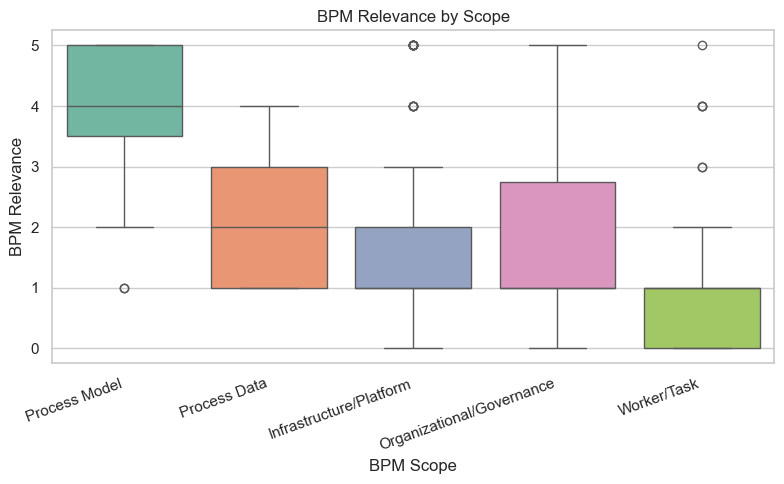

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
order = df.groupby("BPM Scope")["BPM Relevance"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="BPM Scope", y="BPM Relevance", order=order, ax=ax, palette="Set2")
ax.set_title("BPM Relevance by Scope")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()


## Top-rated guidelines

The highest-relevance guidelines across all sources — useful as a starting shortlist for
whatever comes next (e.g. seeding the real interview, or picking candidates for a BPMN pattern
library).


In [11]:
top = (
    df.sort_values("BPM Relevance", ascending=False)
    .loc[:, ["Source", "ID", "Name", "BPM Relevance", "BPM Scope", "Generic"]]
    .head(20)
    .reset_index(drop=True)
)
top


,Source,ID,Name,BPM Relevance,BPM Scope,Generic
0,ppatterns,PPA.6,Shift Workload,5,Process Model,No
1,aws,AWS.Region.1,Choose Region based on both business requirements and sustainability goals,5,Infrastructure/Platform,Yes
2,aws,AWS.Demand.1,Scale workload infrastructure dynamically,5,Worker/Task,No
3,ppatterns,PPA.5,Human Process Performance,5,Process Model,No
4,ppatterns,PPA.4,Green Variant,5,Process Model,No
5,aws,AWS.Demand.6,Implement buffering or throttling to flatten the demand curve,5,Process Model,No
6,ppatterns,PPA.2,Green Compensation,5,Process Model,No
7,w3c,W3C.HOSTING.9,Assess the impact and requirements of data processing,5,Process Model,No
8,azure,MA.REL.21,Tune autoscaling behavior to avoid aggressive short-term scaling reactions,5,Infrastructure/Platform,No
9,azure,MA.REL.24,"Evaluate carbon intensity, latency, and resiliency tradeoffs together when s...",5,Infrastructure/Platform,No


## Claude vs. human ratings (stub — activates once `survey.csv` is filled in)

Right now every source's `survey.csv` is empty (header-only), reserved for the real interview
pass. Once it has data, re-run this cell: it merges the human ratings against
`survey_claude.csv` on `ID` and reports agreement.


In [12]:
def load_human_survey(source):
    path = GUIDELINES_DIR / source / "survey.csv"
    human = pd.read_csv(path, encoding="utf-8-sig")
    human = human.dropna(subset=["BPM Relevance"])
    human.insert(0, "Source", source)
    return human

human_frames = [load_human_survey(s) for s in SOURCES]
human_df = pd.concat(human_frames, ignore_index=True) if human_frames else pd.DataFrame()

if human_df.empty:
    print("No human ratings yet — survey.csv is still empty for every source.")
    print("Once ratings exist, this cell will merge them against survey_claude.csv on ID")
    print("and can report agreement (e.g. correlation, confusion matrix, mean absolute")
    print("difference in BPM Relevance) between the human interview and the Claude pass.")
else:
    claude_df = df[["Source", "ID", "BPM Relevance", "BPM Scope", "Generic"]].rename(
        columns={"BPM Relevance": "Claude Relevance", "BPM Scope": "Claude Scope", "Generic": "Claude Generic"}
    )
    human_df["BPM Relevance"] = pd.to_numeric(human_df["BPM Relevance"], errors="coerce")
    compare = human_df.merge(claude_df, on=["Source", "ID"], how="inner")
    compare["Abs Diff"] = (compare["BPM Relevance"] - compare["Claude Relevance"]).abs()

    print(f"{len(compare)} guidelines have both a human and a Claude rating.")
    print(f"Mean absolute difference in BPM Relevance: {compare['Abs Diff'].mean():.2f}")
    print(f"Exact agreement: {(compare['Abs Diff'] == 0).mean() * 100:.1f}%")

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(data=compare, x="Claude Relevance", y="BPM Relevance", hue="Source", ax=ax)
    ax.plot([0, 5], [0, 5], linestyle="--", color="gray")
    ax.set_title("Human vs. Claude BPM Relevance")
    plt.tight_layout()
    plt.show()


No human ratings yet — survey.csv is still empty for every source.
Once ratings exist, this cell will merge them against survey_claude.csv on ID
and can report agreement (e.g. correlation, confusion matrix, mean absolute
difference in BPM Relevance) between the human interview and the Claude pass.
